# 03 - Time Series Analysis

## Temporal Patterns in Industrial Energy Demand

This notebook examines how industrial energy demand changes over time and whether extreme-demand events show useful patterns before they occur.

The main goals are:
- understand short-term demand behavior
- examine how long extreme-demand episodes last
- study demand before new extreme episodes
- compare pre-event behavior across assets and equipment types
- identify useful temporal patterns for feature engineering

## 1. Loading and Ordering the Data

I load the cleaned dataset, convert the timestamp to datetime format, and sort the observations by asset and time before carrying out the time-series analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data_processed/manufacturing_energy_clean.csv"
)

In [4]:
df["window_start_utc"] = pd.to_datetime(
    df["window_start_utc"]
)

df = df.sort_values(
    ["AssetId", "window_start_utc"]
).reset_index(drop=True)

print(df.shape)

df[["AssetId", "window_start_utc", "Demand_kW"]].head()

(1016182, 16)


,AssetId,window_start_utc,Demand_kW
0,ahu_a,2024-12-31 08:30:00,0.013069
1,ahu_a,2024-12-31 08:45:00,0.014416
2,ahu_a,2024-12-31 09:00:00,0.013955
3,ahu_a,2024-12-31 09:15:00,0.013948
4,ahu_a,2024-12-31 09:30:00,0.014930


### Checking Time Gaps

Because the measurements should occur every 15 minutes, I check the time difference between consecutive observations within each asset.

In [5]:
df["time_gap"] = (
    df.groupby("AssetId")["window_start_utc"]
    .diff()
)

df["time_gap"].value_counts().head(10)

time_gap
0 days 00:15:00    1014972
0 days 00:30:00        297
0 days 00:45:00        130
0 days 01:00:00         86
0 days 01:15:00         46
0 days 01:30:00         40
0 days 01:45:00         38
0 days 06:45:00         38
0 days 09:00:00         35
0 days 02:00:00         27
Name: count, dtype: int64

**Finding:** Most consecutive observations are exactly 15 minutes apart, with only a small number of larger gaps. These gaps need to be considered when creating lag-based features.

## 2. Demand Behavior Over Time

I first look at one week of demand for asset `p_k`, the largest operational energy consumer identified in the previous notebook.

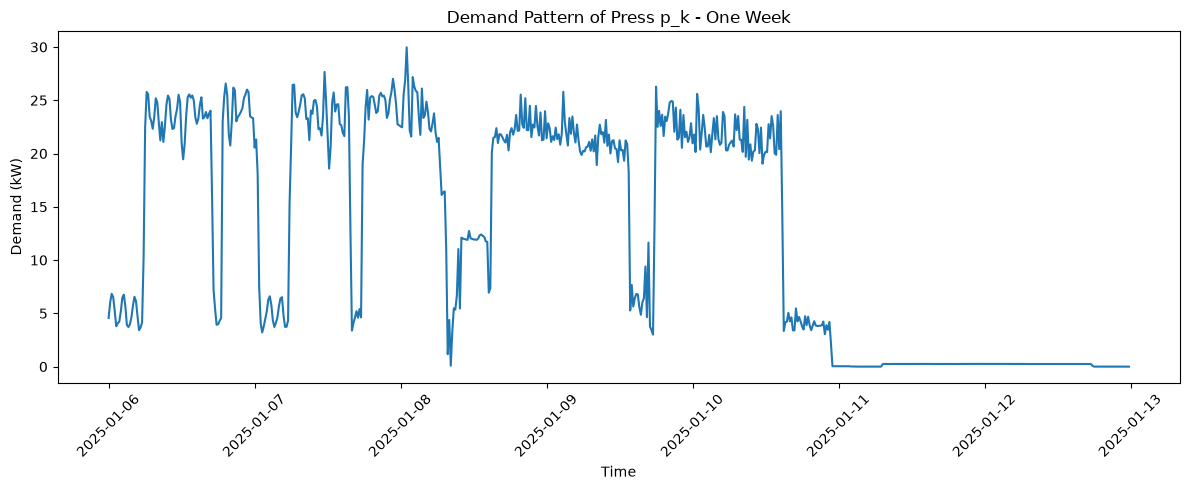

In [6]:
pk = df[df["AssetId"] == "p_k"].copy()

pk_week = pk[
    (pk["window_start_utc"] >= "2025-01-06") &
    (pk["window_start_utc"] < "2025-01-13")
]

plt.figure(figsize=(12, 5))

plt.plot(pk_week["window_start_utc"], pk_week["Demand_kW"])

plt.title("Demand Pattern of Press p_k - One Week")
plt.xlabel("Time")
plt.ylabel("Demand (kW)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Finding:** The demand profile shows clear operating states rather than random fluctuations. High-demand periods can last for several hours and are separated by sharp changes to lower-demand or inactive states.

In [7]:
pk_threshold = pk["Demand_kW"].quantile(0.90)

pk["is_extreme"] = (
    pk["Demand_kW"] > pk_threshold
).astype(int)

print("Extreme threshold:", pk_threshold)
print(pk["is_extreme"].value_counts())

Extreme threshold: 47.83373322444446
is_extreme
0    30589
1     3399
Name: count, dtype: int64


## 3. Extreme-Demand Episodes

Extreme observations may occur as isolated peaks or as consecutive periods. I group consecutive extreme observations into episodes to see how long high-demand conditions usually last.

In [8]:
pk["new_episode"] = (
    (pk["is_extreme"] == 1) &
    (pk["is_extreme"].shift(1) != 1)
)

pk["episode_id"] = pk["new_episode"].cumsum()

pk_extreme = pk[pk["is_extreme"] == 1]

episode_length = (
    pk_extreme.groupby("episode_id")
    .size()
)

episode_length.describe()

count    1413.000000
mean        2.405520
std         2.500232
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        34.000000
dtype: float64

**Finding:** For `p_k`, the median extreme-demand episode lasts about 30 minutes, while 75% last 45 minutes or less. Some episodes continue for several hours, so extreme demand includes both short peaks and sustained high-demand periods.

## 4. Demand Before a New Extreme Episode

I examine demand 15, 30, 45 and 60 minutes before the start of each new extreme-demand episode to see whether a warning pattern is visible.

In [9]:
pk["demand_15m_ago"] = pk["Demand_kW"].shift(1)
pk["demand_30m_ago"] = pk["Demand_kW"].shift(2)
pk["demand_45m_ago"] = pk["Demand_kW"].shift(3)
pk["demand_60m_ago"] = pk["Demand_kW"].shift(4)

In [10]:
episode_starts = pk[
    pk["new_episode"] == True
]

episode_starts[
    [
        "demand_60m_ago",
        "demand_45m_ago",
        "demand_30m_ago",
        "demand_15m_ago",
        "Demand_kW"
    ]
].median()

demand_60m_ago    45.982729
demand_45m_ago    45.774924
demand_30m_ago    45.563909
demand_15m_ago    45.082887
Demand_kW         49.381352
dtype: float64

**Finding:** For `p_k`, demand does not show a clear gradual increase before a new extreme episode. Instead, median demand remains around 45–46 kW during the preceding hour, close to the asset's 47.8 kW extreme-demand threshold, before crossing into the extreme range. This suggests that sustained operation near the threshold may be more informative than a simple upward trend.

The thresholds in this notebook are calculated from the full dataset for descriptive analysis only. In the machine-learning pipeline, thresholds are calculated using the training period only to avoid look-ahead bias.

## 5. One-Hour Warning Signal Across Assets

I now repeat the analysis across all assets. Because different assets operate at very different demand levels, I compare demand with each asset's own extreme-demand threshold.

In [11]:
thresholds = (
    df.groupby("AssetId")["Demand_kW"]
    .quantile(0.90)
)

df["extreme_threshold"] = df["AssetId"].map(thresholds)

df["is_extreme"] = (
    df["Demand_kW"] > df["extreme_threshold"]
).astype(int)

df["previous_extreme"] = (
    df.groupby("AssetId")["is_extreme"]
    .shift(1)
)

df["new_episode"] = (
    (df["is_extreme"] == 1) &
    (df["previous_extreme"] != 1)
)

df["demand_15m_ago"] = (
    df.groupby("AssetId")["Demand_kW"]
    .shift(1)
)

df["demand_30m_ago"] = (
    df.groupby("AssetId")["Demand_kW"]
    .shift(2)
)

df["demand_45m_ago"] = (
    df.groupby("AssetId")["Demand_kW"]
    .shift(3)
)

df["demand_1h_ago"] = (
    df.groupby("AssetId")["Demand_kW"]
    .shift(4)
)

df["ratio_1h_before"] = (
    df["demand_1h_ago"] /
    df["extreme_threshold"]
)

In [12]:
print(
    "Assets with zero threshold:",
    (thresholds == 0).sum()
)

Assets with zero threshold: 2


### Validating the One-Hour Signal

Some assets have a zero extreme-demand threshold because they are inactive for much of the dataset. There are also a small number of timestamp gaps.

I therefore keep only new extreme episodes with a positive threshold and a historical observation exactly one hour earlier.

In [13]:
df["time_1h_ago"] = (
    df.groupby("AssetId")["window_start_utc"]
    .shift(4)
)

df["gap_1h"] = (
    df["window_start_utc"] -
    df["time_1h_ago"]
)

In [14]:
valid_new_extremes = df[
    (df["new_episode"] == True) &
    (df["extreme_threshold"] > 0) &
    (df["gap_1h"] == pd.Timedelta(hours=1))
].copy()

### New Episodes That Were Not Extreme One Hour Earlier

A new episode can still have been extreme one hour earlier if the asset briefly returned to normal between two extreme periods.

For a stricter early-warning test, I keep only episodes where demand was below the extreme threshold exactly one hour before the event.

In [15]:
true_early_warning = valid_new_extremes[
    valid_new_extremes["demand_1h_ago"] <=
    valid_new_extremes["extreme_threshold"]
].copy()

print("Episodes:", len(true_early_warning))

true_early_warning["ratio_1h_before"].describe()

Episodes: 14825


count    14825.000000
mean         0.679085
std          0.332664
min          0.000000
25%          0.415412
50%          0.828853
75%          0.955315
max          1.000000
Name: ratio_1h_before, dtype: float64

**Finding:** Even after excluding episodes where the asset was already in an extreme state one hour earlier, a strong pre-event signal remains. Across 14,825 new extreme episodes, median demand one hour before the event was approximately 82.9% of the asset-specific extreme-demand threshold. For 25% of these episodes, demand was already above approximately 95.5% of the threshold.

This suggests that many new extreme-demand episodes show an observable warning condition before the threshold is crossed. However, the wide distribution also shows that proximity to the threshold alone will not identify every event, motivating the use of additional temporal and operational features in the machine learning model.

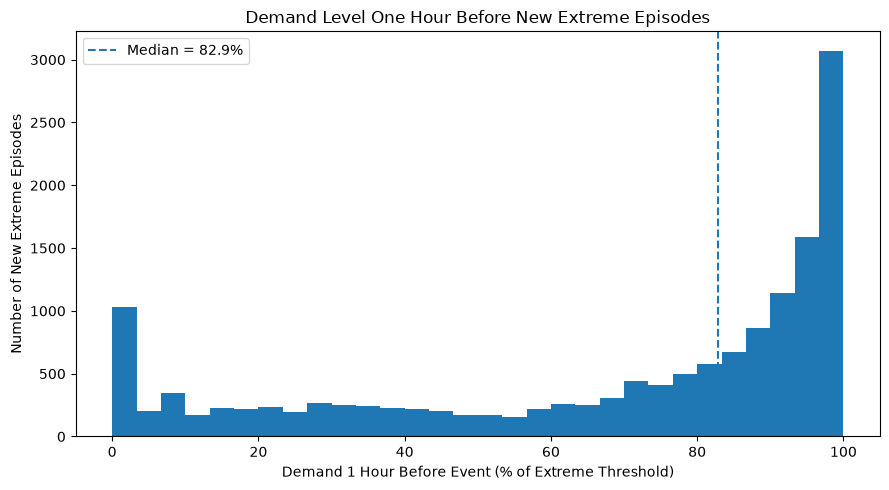

In [16]:
median_ratio = (
    true_early_warning["ratio_1h_before"].median()
    * 100
)

plt.figure(figsize=(9, 5))

plt.hist(
    true_early_warning["ratio_1h_before"] * 100,
    bins=30
)

plt.axvline(
    median_ratio,
    linestyle="--",
    label=f"Median = {median_ratio:.1f}%"
)

plt.xlabel("Demand 1 Hour Before Event (% of Extreme Threshold)")
plt.ylabel("Number of New Extreme Episodes")
plt.title("Demand Level One Hour Before New Extreme Episodes")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Different Levels of Advance Warning

Not every new extreme-demand episode shows the same warning pattern. I group episodes according to how close demand was to the extreme threshold one hour before the event.

In [17]:
true_early_warning["warning_level"] = pd.cut(
    true_early_warning["ratio_1h_before"],
    bins=[-0.01, 0.50, 0.75, 0.90, 1.00],
    labels=[
        "Below 50%",
        "50–75%",
        "75–90%",
        "90–100%"
    ]
)

warning_groups = (
    true_early_warning["warning_level"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

warning_groups

warning_level
Below 50%    28.330523
50–75%       13.497470
75–90%       19.075885
90–100%      39.096121
Name: proportion, dtype: float64

**Finding:** New extreme-demand episodes show different levels of advance warning. Around 39.1% were already operating at 90–100% of their extreme threshold one hour before the event. However, 28.3% were below 50% of the threshold one hour earlier.

This suggests that some extreme-demand episodes develop from an obvious high-demand warning state, while a substantial group occurs after much lower demand levels. These lower-demand cases may represent a more difficult early-warning problem and will be investigated separately during model evaluation and error analysis.

## 7. Demand Trajectory Before Lower-Demand Events

Some new extreme episodes begin from relatively low demand one hour earlier. I examine how demand changes during the final hour before these events.

In [18]:
lower_demand_events = true_early_warning[
    true_early_warning["ratio_1h_before"] < 0.50
].copy()

print("Lower-demand events:", len(lower_demand_events))

Lower-demand events: 4200


In [19]:
lower_demand_events["ratio_45m"] = (
    lower_demand_events["demand_45m_ago"] /
    lower_demand_events["extreme_threshold"]
)

lower_demand_events["ratio_30m"] = (
    lower_demand_events["demand_30m_ago"] /
    lower_demand_events["extreme_threshold"]
)

lower_demand_events["ratio_15m"] = (
    lower_demand_events["demand_15m_ago"] /
    lower_demand_events["extreme_threshold"]
)

In [20]:
trajectory = pd.Series({
    "60 min before": lower_demand_events["ratio_1h_before"].median() * 100,
    "45 min before": lower_demand_events["ratio_45m"].median() * 100,
    "30 min before": lower_demand_events["ratio_30m"].median() * 100,
    "15 min before": lower_demand_events["ratio_15m"].median() * 100,
    "Extreme start": (
        lower_demand_events["Demand_kW"] /
        lower_demand_events["extreme_threshold"]
    ).median() * 100
})

trajectory

60 min before     18.649632
45 min before     22.245418
30 min before     29.098340
15 min before     48.174088
Extreme start    117.954165
dtype: float64

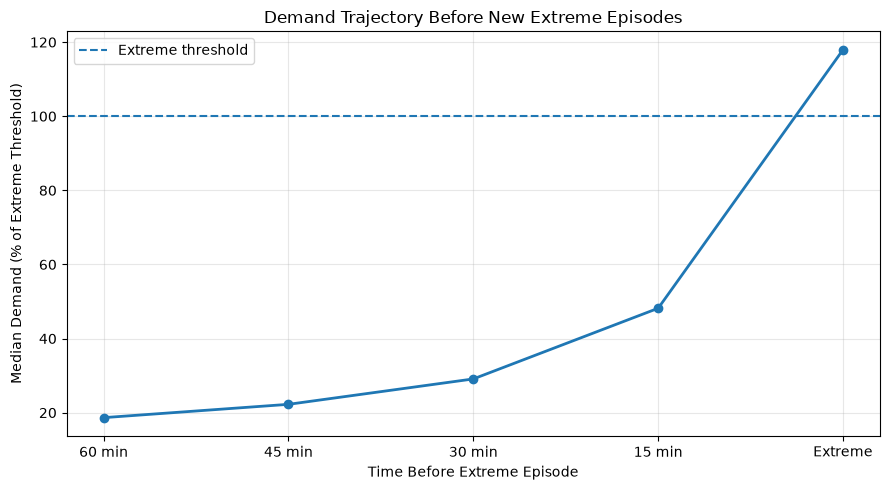

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    ["60 min", "45 min", "30 min", "15 min", "Extreme"],
    trajectory.values,
    marker="o",
    linewidth=2
)

plt.axhline(
    100,
    linestyle="--",
    label="Extreme threshold"
)

plt.title("Demand Trajectory Before New Extreme Episodes")
plt.xlabel("Time Before Extreme Episode")
plt.ylabel("Median Demand (% of Extreme Threshold)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Finding:** For new extreme episodes that were below 50% of the asset-specific threshold one hour earlier, median demand increased from 18.6% of the threshold at 60 minutes before the event to 48.2% at 15 minutes before the event, before reaching approximately 118% when the extreme episode began.

This accelerating pattern suggests that short-term demand changes may provide useful predictive information even for events that appear relatively low-risk one hour beforehand.

## 8. Pre-Event Signal by Equipment Type

Different equipment types may show different demand patterns before an extreme event. I compare the one-hour pre-event demand level across asset types.

In [22]:
warning_by_type = (
    true_early_warning
    .groupby("asset_type")["ratio_1h_before"]
    .agg(["median", "count"])
)

warning_by_type["median_pct"] = (
    warning_by_type["median"] * 100
)

warning_by_type = warning_by_type.sort_values(
    "median_pct",
    ascending=False
)

warning_by_type

,median,count,median_pct
asset_type,,,
HVAC_AirExtraction,0.993554,483,99.355411
HVAC_AHU,0.970489,653,97.048943
HVAC_HeatPump,0.953204,462,95.320413
Electrical_GridImport,0.906660,230,90.665976
CompressedAir,0.899356,584,89.935617
Press_IntegratedAutomationCell,0.875944,467,87.594436
Utilities,0.855842,1457,85.584189
Press_Main,0.841249,4725,84.124862
Press_Drive,0.826564,1103,82.656357


**Finding:** The one-hour pre-event signal differs substantially across equipment types. HVAC systems typically operate close to their extreme-demand threshold one hour before a new extreme episode, while Process Mixing and Automation Handling show much lower pre-event demand levels.

For example, the median one-hour pre-event demand is approximately 99% of the threshold for HVAC Air Extraction, compared with only 40% for Process Mixing. This suggests that a single fixed warning rule may not work equally well across all equipment types and supports the use of asset-specific information in the prediction model.

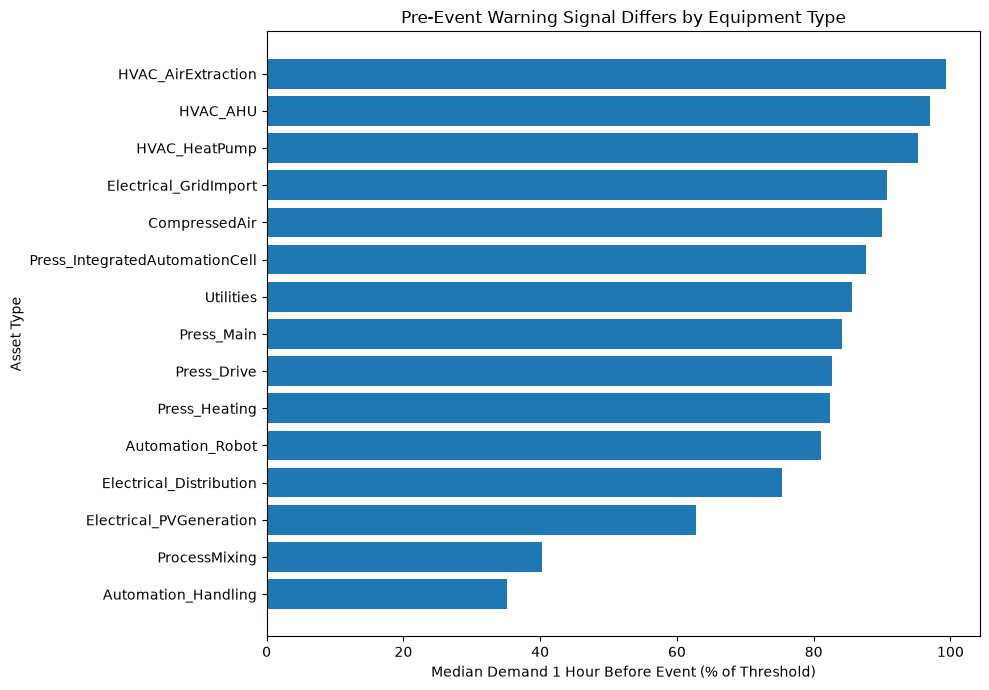

In [23]:
plot_data = warning_by_type.sort_values("median_pct")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data.index,
    plot_data["median_pct"]
)

plt.xlabel("Median Demand 1 Hour Before Event (% of Threshold)")
plt.ylabel("Asset Type")
plt.title("Pre-Event Warning Signal Differs by Equipment Type")

plt.tight_layout()
plt.show()

## 9. Relationship Between Recent and Current Demand

I measure how strongly current demand is related to demand 15, 30, 45 and 60 minutes earlier.

In [24]:
lag_columns = [
    "demand_15m_ago",
    "demand_30m_ago",
    "demand_45m_ago",
    "demand_1h_ago"
]

lag_correlations = df[
    ["Demand_kW"] + lag_columns
].corr()["Demand_kW"][lag_columns]

lag_correlations

demand_15m_ago    0.990124
demand_30m_ago    0.984081
demand_45m_ago    0.979594
demand_1h_ago     0.975439
Name: Demand_kW, dtype: float64

**Finding:** Current demand is strongly related to recent demand. The correlation decreases gradually from 0.990 at a 15-minute lag to 0.975 at a one-hour lag. This confirms strong short-term persistence in equipment demand and supports the use of recent demand history as predictive features.

However, these correlations describe overall temporal persistence and do not by themselves demonstrate that extreme-demand events can be predicted one hour ahead.

## 10. Summary and Implications for Feature Engineering

The time-series analysis revealed several useful patterns:

- Industrial demand shows strong short-term persistence.
- Extreme-demand periods can appear as both short peaks and sustained episodes.
- For `p_k`, the median extreme episode lasts about 30 minutes.
- Across new extreme episodes that were not already extreme one hour earlier, median demand was about 82.9% of the asset-specific threshold one hour before the event.
- Around 39.1% of these episodes were already at 90–100% of their threshold one hour earlier, while 28.3% were below 50%.
- Lower-demand events often show a strong increase during the final hour before the event.
- Pre-event behavior differs considerably across equipment types.

These results support the use of recent demand lags, demand changes, rolling behavior, time information and asset characteristics in the feature-engineering stage.

## 11. Presentation Visual - High-Demand Event Over Time

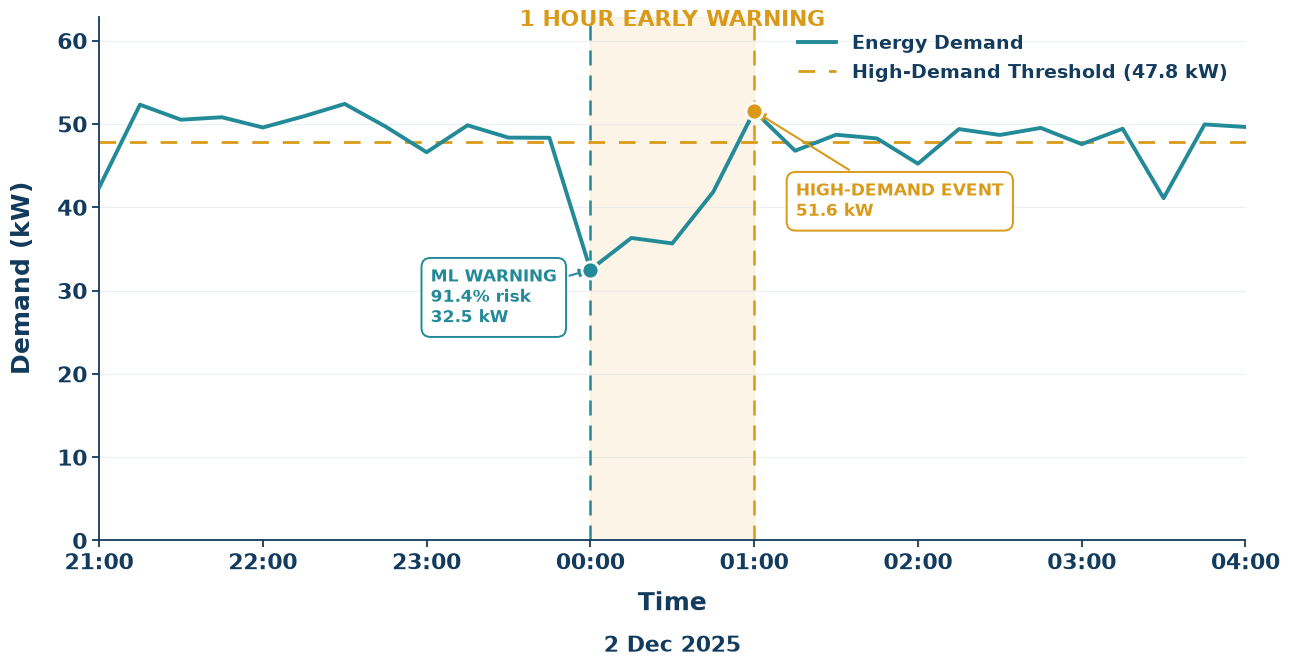

In [25]:
import matplotlib.dates as mdates

asset_id = "p_k"

# Validated successful Random Forest warning
warning_time = pd.Timestamp("2025-12-02 00:00:00")
event_time = pd.Timestamp("2025-12-02 01:00:00")
rf_probability = 0.914440

# ---------------------------------------------------------
# Exact presentation colors
# ---------------------------------------------------------

navy = "#123B5D"
teal = "#238A98"
gold = "#D99A18"

light_teal = "#EAF4F5"
light_gold = "#FFF6DF"

axis_grey = "#44546A"
grid_grey = "#DDE5EA"

# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

asset = df[df["AssetId"] == asset_id].copy()

# Show 21:00 → 04:00
start_time = pd.Timestamp("2025-12-01 21:00:00")
end_time = pd.Timestamp("2025-12-02 04:00:00")

plot_data = asset[
    (asset["window_start_utc"] >= start_time) &
    (asset["window_start_utc"] <= end_time)
].copy()

threshold = asset["extreme_threshold"].iloc[0]

warning_demand = plot_data.loc[
    plot_data["window_start_utc"] == warning_time,
    "Demand_kW"
].iloc[0]

event_demand = plot_data.loc[
    plot_data["window_start_utc"] == event_time,
    "Demand_kW"
].iloc[0]


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7))

fig.patch.set_alpha(0)
ax.set_facecolor("white")


# ---------------------------------------------------------
# Warning window shading
# ---------------------------------------------------------

ax.axvspan(
    warning_time,
    event_time,
    color=gold,
    alpha=0.10,
    zorder=0
)


# ---------------------------------------------------------
# Demand line
# ---------------------------------------------------------

ax.plot(
    plot_data["window_start_utc"],
    plot_data["Demand_kW"],
    color=teal,
    linewidth=2.8,
    label="Energy Demand",
    zorder=3
)


# ---------------------------------------------------------
# High-demand threshold
# ---------------------------------------------------------

ax.axhline(
    threshold,
    color=gold,
    linestyle=(0, (6, 5)),
    linewidth=2,
    label=f"High-Demand Threshold ({threshold:.1f} kW)",
    zorder=2
)


# ---------------------------------------------------------
# Warning + event vertical lines
# ---------------------------------------------------------

ax.axvline(
    warning_time,
    color=teal,
    linestyle=(0, (6, 4)),
    linewidth=1.8,
    zorder=2
)

ax.axvline(
    event_time,
    color=gold,
    linestyle=(0, (6, 4)),
    linewidth=1.8,
    zorder=2
)


# ---------------------------------------------------------
# Warning + event points
# ---------------------------------------------------------

ax.scatter(
    warning_time,
    warning_demand,
    s=150,
    color=teal,
    edgecolor="white",
    linewidth=2,
    zorder=5
)

ax.scatter(
    event_time,
    event_demand,
    s=150,
    color=gold,
    edgecolor="white",
    linewidth=2,
    zorder=5
)


# ---------------------------------------------------------
# Top labels
# ---------------------------------------------------------

y_top = plot_data["Demand_kW"].max() * 1.08


# ---------------------------------------------------------
# Warning annotation box
# ---------------------------------------------------------

ax.annotate(
    f"ML WARNING\n{rf_probability * 100:.1f}% risk\n{warning_demand:.1f} kW",
    xy=(warning_time, warning_demand),
    xytext=(-115, -20),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold",
    color=teal,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=teal,
        linewidth=1.4
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=teal,
        linewidth=1.5
    )
)


# ---------------------------------------------------------
# Event annotation box
# ---------------------------------------------------------

ax.annotate(
    f"HIGH-DEMAND EVENT\n{event_demand:.1f} kW",
    xy=(event_time, event_demand),
    xytext=(30, -65),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold",
    color=gold,
    ha="left",
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor=gold,
        linewidth=1.4
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=gold,
        linewidth=1.5
    )
)


# ---------------------------------------------------------
# One-hour early-warning label
# ---------------------------------------------------------

middle_time = warning_time + pd.Timedelta(minutes=30)

y_warning_text = max(
    warning_demand,
    threshold * 0.68
)

# Put the text ABOVE the warning/event area
ax.text(
    middle_time,
    y_top * 1.08,   # increase this number to move it higher
    "1 HOUR EARLY WARNING",
    ha="center",
    va="bottom",
    fontsize=16,
    fontweight="bold",
    color=gold
)


# ---------------------------------------------------------
# X-axis
# Show hourly ticks only
# ---------------------------------------------------------

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

# Exact visible time range
ax.set_xlim(
    start_time,
    end_time
)

# Add date separately
ax.text(
    0.5,
    -0.18,
    "2 Dec 2025",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16,
    fontweight="bold",
    color=navy
)


# ---------------------------------------------------------
# Y-axis
# Real Demand_kW values
# ---------------------------------------------------------

y_max = max(
    plot_data["Demand_kW"].max(),
    threshold,
    event_demand
)

ax.set_ylim(
    0,
    y_max * 1.20
)

ax.set_ylabel(
    "Demand (kW)",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=16
)

ax.set_xlabel(
    "Time",
    fontsize=18,
    fontweight="bold",
    color=navy,
    labelpad=12
)


# ---------------------------------------------------------
# Bigger axis numbers
# ---------------------------------------------------------

ax.tick_params(
    axis="x",
    labelsize=16,
    colors=navy,
    width=1.3,
    length=5
)

ax.tick_params(
    axis="y",
    labelsize=16,
    colors=navy,
    width=1.3,
    length=5
)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------

ax.grid(
    axis="y",
    color=grid_grey,
    linewidth=0.8,
    alpha=0.55
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)


# ---------------------------------------------------------
# Spines
# ---------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(navy)
ax.spines["bottom"].set_color(navy)

ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend = ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=14
)

for text in legend.get_texts():
    text.set_color(navy)
    text.set_fontweight("bold")


# ---------------------------------------------------------
# Final spacing
# ---------------------------------------------------------

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.savefig(
    "../presentation/one_hour_early_warning.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()